# BẢNG ĐÁNH GIÁ HIỆU SUẤT ĐÓNG GÓP NHÓM

| Họ và tên | MSSV | Hiệu suất đóng góp |
|---|---|---|
| Huỳnh Thế Hy | 051205009083 | ...% |
| Thành viên 2 | MSSV 2 | ... % |
| Thành viên 3 | MSSV 3 | ... % |
| Thành viên 4 | MSSV 4 | ... % |
| Thành viên 5 | MSSV 5 | ... % |
| Thành viên 6 | MSSV 6 | ... % |

---

## Phần 1: Giới thiệu bài toán FrozenLake

### 1.1 Mô tả bài toán

FrozenLake là một môi trường lưới 4×4 (16 ô) hoặc 8×8 (64 ô). Agent (nhân vật) phải đi từ ô **START (S)** đến ô **GOAL (G)** mà không bị rơi vào ô **lỗ (H - Hole)**. Các ô băng an toàn được ký hiệu là **F (Frozen)**.

```
S F F F
F H F H
F F F H
H F F G
```

### 1.2 Các thành phần của môi trường

| Thành phần | Mô tả |
|---|---|
| **State space** | 16 ô (4×4), rời rạc |
| **Action space** | 4 hướng: LEFT(0), DOWN(1), RIGHT(2), UP(3) |
| **Reward** | +1 nếu đến đích, 0 còn lại |
| **Stochastic** | `is_slippery=True` → agent có thể trượt sang hướng khác |

### 1.3 Mục tiêu bài lab

- Cài đặt **Q-learning** (off-policy) và **SARSA** (on-policy)
- So sánh sự khác nhau giữa hai thuật toán
- Hiểu vai trò của ε-greedy trong việc khám phá môi trường
- Đánh giá agent sau khi huấn luyện

## Phần 2: Khởi tạo môi trường

In [1]:
# Import các thư viện cần thiết
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Tạo 2 môi trường: có trượt và không có trượt
env_slip    = gym.make('FrozenLake-v1', is_slippery=True)   # môi trường ngẫu nhiên
env_noSlip  = gym.make('FrozenLake-v1', is_slippery=False)  # môi trường xác định

# In thông tin môi trường
print("Thông tin môi trường")
print(f"Số trạng thái (states) : {env_slip.observation_space.n}")
print(f"Số hành động (actions) : {env_slip.action_space.n}")

Thông tin môi trường
Số trạng thái (states) : 16
Số hành động (actions) : 4


### Ý nghĩa các hành động:
- 0 = LEFT (đi trái)
- 1 = DOWN (đi xuống)
- 2 = RIGHT (đi phải)
- 3 = UP (đi lên)

### Cấu trúc lưới 4x4

|   |   |   |   |
|---|---|---|---|
| S | F | F | F |
| F | H | F | H |
| F | F | F | H |
| H | F | F | G |

(S = Start, F = Frozen, H = Hole, G = Goal)

## Phần 3: Q-learning

### 3.1 Lý thuyết ngắn gọn

**Q-learning** là thuật toán **off-policy** — tức là khi cập nhật, nó dùng hành động **tốt nhất có thể** (max Q) thay vì hành động agent thực sự sẽ làm tiếp theo.

Công thức cập nhật:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \right]$$

Trong đó:
- $\alpha$: learning rate (tốc độ học)
- $\gamma$: discount factor (coi trọng phần thưởng tương lai bao nhiêu)
- $r$: reward nhận được
- $s'$: trạng thái tiếp theo

## Chiến lược tối ưu hoá tỉ lệ thắng

Để đạt tỉ lệ thắng tối đa trên FrozenLake stochastic, em áp dụng **5 cải tiến** sau:

| # | Cải tiến | Cũ → Mới | Lý do |
|---|---|---|---|
| 1 | **Learning rate α** | 0.8 → **0.1** | α cao gây Q-value dao động, không ổn định với môi trường ngẫu nhiên |
| 2 | **Discount γ** | 0.95 → **0.99** | Goal chỉ có +1 ở cuối, cần coi trọng phần thưởng xa hơn |
| 3 | **Epsilon floor** | 0.01 → **0.001** | Cho phép khai thác tốt hơn ở giai đoạn cuối |
| 4 | **Epsilon decay** | 0.995 → **0.9995** | Môi trường stochastic cần khám phá lâu hơn để ước tính đúng xác suất |
| 5 | **Số episodes** | 10,000 → **30,000** | Cần đủ dài để Q-table hội tụ ở môi trường ngẫu nhiên |
| 6 | **Best Q tracking** | không có → **có** | Lưu lại Q-table tốt nhất trong quá trình học, tránh overshoot |
| 7 | **Tie-breaking** | không có → **có** | Khi Q bằng nhau lúc đầu, tránh luôn chọn action 0 (LEFT) |

> **Lý thuyết nền:** Với FrozenLake `is_slippery=True`, agent có xác suất 1/3 trượt sang hướng vuông góc.  
> Môi trường này cần **nhiều episodes + decay chậm** để ước lượng đúng giá trị Q dưới randomness.


In [3]:
n_states  = env_slip.observation_space.n   # 16 trạng thái
n_actions = env_slip.action_space.n        # 4 hành động

alpha     = 0.1 # Learning rate thấp hơn → ổn định hơn, không bị overwrite Q tốt
gamma     = 0.99 # Discount cao → coi trọng phần thưởng tương lai (goal xa mới +1)
epsilon   = 1.0 # Epsilon floor thấp → khai thác nhiều hơn khi đã học
eps_min   = 0.001 # Decay chậm → khám phá đủ dài trên môi trường stochastic
eps_decay = 0.9995 # Nhiều episode hơn để Q-table hội tụ đầy đủ
n_episodes = 30000

In [4]:
def epsilon_greedy(Q, state, eps):
    """
    Epsilon-greedy có tie-breaking:
    Khi nhiều hành động có Q bằng nhau → chọn ngẫu nhiên trong đó
    (tránh luôn chọn action 0 = LEFT khi Q-table toàn số 0 lúc đầu)
    """
    if np.random.random() < eps:
        return np.random.randint(n_actions)
    else:
        max_q = np.max(Q[state])
        ties  = np.where(Q[state] == max_q)[0]
        return np.random.choice(ties)


def train_qlearning(env, n_episodes, alpha, gamma, epsilon, eps_min, eps_decay):
    """
    Q-learning tối ưu với:
    - Tie-breaking trong epsilon-greedy
    - Tracking best Q-table (lấy Q tốt nhất trong toàn quá trình)
    """
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_ep = []
    eps = epsilon

    # Theo dõi Q-table tốt nhất (dùng win rate trên 500 ep gần nhất)
    best_Q   = Q.copy()
    best_win = 0.0

    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            # Chọn hành động theo epsilon-greedy
            action = epsilon_greedy(Q, state, eps)

            # Thực hiện hành động
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # ── Cập nhật Q-learning (off-policy) ──
            # Dùng max Q(s') — hành động tốt nhất giả định
            best_next = np.max(Q[next_state]) if not done else 0.0
            td_target = reward + gamma * best_next
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward

        eps = max(eps_min, eps * eps_decay)
        rewards_per_ep.append(total_reward)

        # Cứ mỗi 500 episode, kiểm tra và lưu Q-table tốt nhất
        if ep >= 500 and ep % 500 == 0:
            recent_win = np.mean(rewards_per_ep[-500:])
            if recent_win > best_win:
                best_win = recent_win
                best_Q   = Q.copy()

    # Trả về Q tốt nhất thay vì Q cuối cùng
    if best_win > 0:
        Q = best_Q

    return Q, rewards_per_ep


# ───── CHẠY HUẤN LUYỆN ─────
print("Đang huấn luyện Q-learning (30,000 episodes)...")
Q_qlearn, rewards_qlearn = train_qlearning(
    env_slip, n_episodes, alpha, gamma, epsilon, eps_min, eps_decay
)

win_rate  = np.mean(rewards_qlearn[-1000:]) * 100
print(f"\n Huấn luyện xong!")
print(f"   Reward TB (toàn bộ)   : {np.mean(rewards_qlearn):.4f}")
print(f"   Tỉ lệ thắng (1k ep cuối): {win_rate:.1f}%")


Đang huấn luyện Q-learning (30,000 episodes)...

 Huấn luyện xong!
   Reward TB (toàn bộ)   : 0.6135
   Tỉ lệ thắng (1k ep cuối): 72.4%


In [5]:
# Hiển thị Q-table đã học
print("Q-TABLE SAU HUẤN LUYỆN (Q-learning):")
print("-" * 55)
print(f"{'State':>6} | {'LEFT':>8} | {'DOWN':>8} | {'RIGHT':>8} | {'UP':>8}")
print("-" * 55)
for s in range(n_states):
    best = np.argmax(Q_qlearn[s])
    actions_str = " | ".join([
        f"{'>>'+f'{Q_qlearn[s,a]:.3f}'+'<<' if a==best else f'{Q_qlearn[s,a]:.3f}':>8}"
        for a in range(n_actions)
    ])
    print(f"  s={s:2d} | {actions_str}")

Q-TABLE SAU HUẤN LUYỆN (Q-learning):
-------------------------------------------------------
 State |     LEFT |     DOWN |    RIGHT |       UP
-------------------------------------------------------
  s= 0 | >>0.498<< |    0.408 |    0.402 |    0.416
  s= 1 |    0.288 |    0.173 |    0.188 | >>0.460<<
  s= 2 |    0.307 |    0.292 |    0.316 | >>0.418<<
  s= 3 |    0.195 |    0.253 |    0.247 | >>0.406<<
  s= 4 | >>0.562<< |    0.368 |    0.395 |    0.359
  s= 5 | >>0.000<< |    0.000 |    0.000 |    0.000
  s= 6 |    0.139 |    0.120 | >>0.391<< |    0.115
  s= 7 | >>0.000<< |    0.000 |    0.000 |    0.000
  s= 8 |    0.419 |    0.364 |    0.450 | >>0.612<<
  s= 9 |    0.426 | >>0.656<< |    0.419 |    0.435
  s=10 | >>0.559<< |    0.347 |    0.321 |    0.292
  s=11 | >>0.000<< |    0.000 |    0.000 |    0.000
  s=12 | >>0.000<< |    0.000 |    0.000 |    0.000
  s=13 |    0.576 |    0.374 | >>0.764<< |    0.508
  s=14 |    0.642 | >>0.903<< |    0.663 |    0.672
  s=15 | >>0.000<< |

In [6]:
# Hiển thị policy học được dạng lưới trực quan
action_symbols = ['←', '↓', '→', '↑']
hole_positions = [5, 7, 11, 12]   # vị trí các lỗ trong bản đồ 4x4
goal_position  = 15

print("\nPOLICY HỌC ĐƯỢC (Q-learning):")
print("   (mỗi ô hiển thị hành động tốt nhất)")
print("+" + "-----+" * 4)
for row in range(4):
    line = "|"
    for col in range(4):
        s = row * 4 + col
        if s == 0:
            cell = "  S  "
        elif s == goal_position:
            cell = "  G  "
        elif s in hole_positions:
            cell = "  H  "
        else:
            best_action = np.argmax(Q_qlearn[s])
            cell = f"  {action_symbols[best_action]}  "
        line += cell + "|"
    print(line)
    print("+" + "-----+" * 4)


POLICY HỌC ĐƯỢC (Q-learning):
   (mỗi ô hiển thị hành động tốt nhất)
+-----+-----+-----+-----+
|  S  |  ↑  |  ↑  |  ↑  |
+-----+-----+-----+-----+
|  ←  |  H  |  →  |  H  |
+-----+-----+-----+-----+
|  ↑  |  ↓  |  ←  |  H  |
+-----+-----+-----+-----+
|  H  |  →  |  ↓  |  G  |
+-----+-----+-----+-----+


## Phần 4: SARSA

### 4.1 Lý thuyết ngắn gọn

**SARSA** là thuật toán **on-policy** — khi cập nhật, nó dùng hành động agent **thực sự sẽ làm tiếp theo** (không phải hành động tốt nhất giả định như Q-learning).

Tên SARSA xuất phát từ: **S**tate → **A**ction → **R**eward → **S**tate' → **A**ction'

Công thức cập nhật:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \cdot Q(s', a') - Q(s, a) \right]$$

Điểm khác biệt quan trọng: **$Q(s', a')$** — dùng hành động $a'$ thực tế (có thể ngẫu nhiên do ε), không phải $\max Q(s')$.

In [7]:
def train_sarsa(env, n_episodes, alpha, gamma, epsilon, eps_min, eps_decay):
    """
    SARSA tối ưu với:
    - Tie-breaking trong epsilon-greedy
    - Tracking best Q-table
    """
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_ep = []
    eps = epsilon

    best_Q   = Q.copy()
    best_win = 0.0

    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        # SARSA chọn action đầu tiên TRƯỚC vòng lặp
        action = epsilon_greedy(Q, state, eps)

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Chọn a' theo epsilon-greedy (on-policy — đây là điểm khác Q-learning)
            next_action = epsilon_greedy(Q, next_state, eps)

            # ── Cập nhật SARSA (on-policy) ──
            # Dùng Q(s', a') thực tế — không phải max
            next_q     = Q[next_state, next_action] if not done else 0.0
            td_target  = reward + gamma * next_q
            Q[state, action] += alpha * (td_target - Q[state, action])

            state  = next_state
            action = next_action
            total_reward += reward

        eps = max(eps_min, eps * eps_decay)
        rewards_per_ep.append(total_reward)

        if ep >= 500 and ep % 500 == 0:
            recent_win = np.mean(rewards_per_ep[-500:])
            if recent_win > best_win:
                best_win = recent_win
                best_Q   = Q.copy()

    if best_win > 0:
        Q = best_Q

    return Q, rewards_per_ep


print("Đang huấn luyện SARSA (30,000 episodes)...")
Q_sarsa, rewards_sarsa = train_sarsa(
    env_slip, n_episodes, alpha, gamma, epsilon, eps_min, eps_decay
)

win_rate_sarsa = np.mean(rewards_sarsa[-1000:]) * 100
print(f"\n Huấn luyện xong!")
print(f"   Reward TB (toàn bộ)   : {np.mean(rewards_sarsa):.4f}")
print(f"   Tỉ lệ thắng (1k ep cuối): {win_rate_sarsa:.1f}%")


Đang huấn luyện SARSA (30,000 episodes)...

 Huấn luyện xong!
   Reward TB (toàn bộ)   : 0.6130
   Tỉ lệ thắng (1k ep cuối): 75.3%


## Phần 5: So sánh Q-learning và SARSA

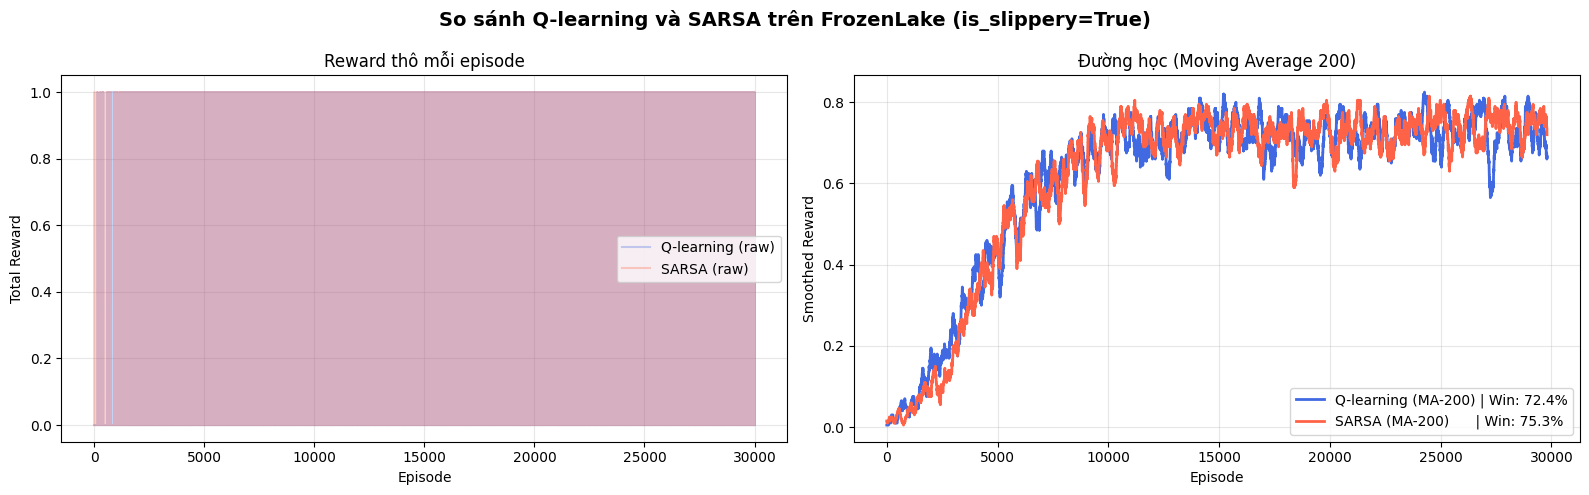

In [8]:
def moving_average(data, window=200):
    """Làm mượt đường bằng cách lấy trung bình trượt."""
    return np.convolve(data, np.ones(window)/window, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('So sánh Q-learning và SARSA trên FrozenLake (is_slippery=True)',
             fontsize=14, fontweight='bold')
# Biểu đồ 1: Reward thô mỗi episode
ax1 = axes[0]
ax1.plot(rewards_qlearn, alpha=0.3, color='royalblue',  label='Q-learning (raw)')
ax1.plot(rewards_sarsa,  alpha=0.3, color='tomato',     label='SARSA (raw)')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Reward thô mỗi episode')
ax1.legend()
ax1.grid(alpha=0.3)

# Biểu đồ 2: Moving average (mượt hơn, dễ thấy xu hướng)
ax2 = axes[1]
smooth_q = moving_average(rewards_qlearn, window=200)
smooth_s = moving_average(rewards_sarsa,  window=200)

ax2.plot(smooth_q, color='royalblue', linewidth=2, label=f'Q-learning (MA-200) | Win: {np.mean(rewards_qlearn[-1000:])*100:.1f}%')
ax2.plot(smooth_s, color='tomato',    linewidth=2, label=f'SARSA (MA-200)      | Win: {np.mean(rewards_sarsa[-1000:])*100:.1f}%')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Smoothed Reward')
ax2.set_title('Đường học (Moving Average 200)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# So sánh số liệu cụ thể
print(f"{'Chỉ số':<30} {'Q-learning':>7} {'SARSA':>7}")
print("-" * 45)
print(f"{'Reward TB (toàn bộ)':<30} {np.mean(rewards_qlearn):>7.4f} {np.mean(rewards_sarsa):>7.4f}")
print(f"{'Reward TB (1000 ep đầu)':<30} {np.mean(rewards_qlearn[:1000]):>7.4f} {np.mean(rewards_sarsa[:1000]):>7.4f}")
print(f"{'Reward TB (1000 ep cuối)':<30} {np.mean(rewards_qlearn[-1000:]):>7.4f} {np.mean(rewards_sarsa[-1000:]):>7.4f}")
print(f"{'Tỉ lệ thắng (1000 ep cuối)':<30} {np.mean(rewards_qlearn[-1000:])*100:>6.1f}% {np.mean(rewards_sarsa[-1000:])*100:>6.1f}%")

Chỉ số                         Q-learning   SARSA
---------------------------------------------
Reward TB (toàn bộ)             0.6135  0.6130
Reward TB (1000 ep đầu)         0.0290  0.0200
Reward TB (1000 ep cuối)        0.7240  0.7530
Tỉ lệ thắng (1000 ep cuối)       72.4%   75.3%


## Phần 6: Thử nghiệm thêm

### 6.1 So sánh is_slippery=True vs False

Huấn luyện trên môi trường is_slippery=False ...


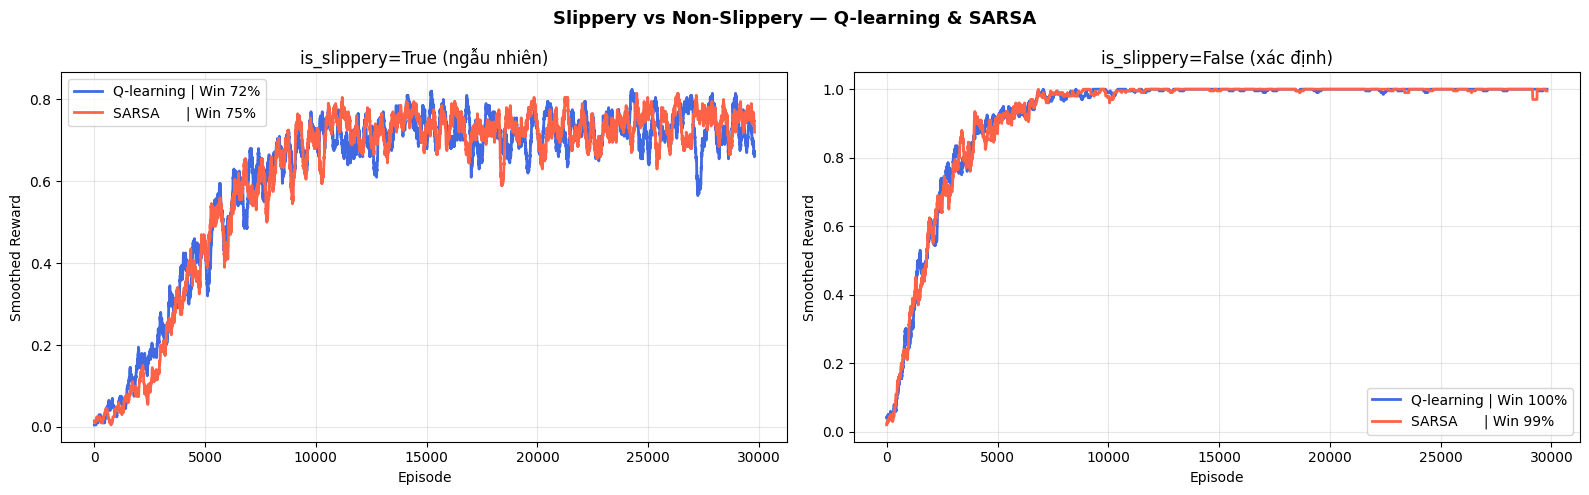


Nhận xét:
  - Khi is_slippery=False: cả 2 thuật toán đều học rất nhanh vì môi trường xác định
  - Khi is_slippery=True:  khó học hơn nhiều do agent bị trượt ngẫu nhiên
  - SARSA thường ổn định hơn trong môi trường nguy hiểm vì thận trọng hơn


In [10]:
# Huấn luyện cả 2 thuật toán trên môi trường KHÔNG trượt
print("Huấn luyện trên môi trường is_slippery=False ...")
Q_ql_noslip, r_ql_noslip = train_qlearning(env_noSlip, n_episodes, alpha, gamma, epsilon, eps_min, eps_decay)
Q_sa_noslip, r_sa_noslip = train_sarsa(env_noSlip, n_episodes, alpha, gamma, epsilon, eps_min, eps_decay)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Slippery vs Non-Slippery — Q-learning & SARSA', fontsize=13, fontweight='bold')

titles = ['is_slippery=True (ngẫu nhiên)', 'is_slippery=False (xác định)']
rewards_pairs = [
    (rewards_qlearn, rewards_sarsa),
    (r_ql_noslip, r_sa_noslip)
]

for i, (ax, title, (rq, rs)) in enumerate(zip(axes, titles, rewards_pairs)):
    sq = moving_average(rq, 200)
    ss = moving_average(rs, 200)
    ax.plot(sq, color='royalblue', lw=2, label=f'Q-learning | Win {np.mean(rq[-1000:])*100:.0f}%')
    ax.plot(ss, color='tomato',    lw=2, label=f'SARSA      | Win {np.mean(rs[-1000:])*100:.0f}%')
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Smoothed Reward')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNhận xét:")
print("  - Khi is_slippery=False: cả 2 thuật toán đều học rất nhanh vì môi trường xác định")
print("  - Khi is_slippery=True:  khó học hơn nhiều do agent bị trượt ngẫu nhiên")
print("  - SARSA thường ổn định hơn trong môi trường nguy hiểm vì thận trọng hơn")

### 6.2 So sánh epsilon decay nhanh vs chậm

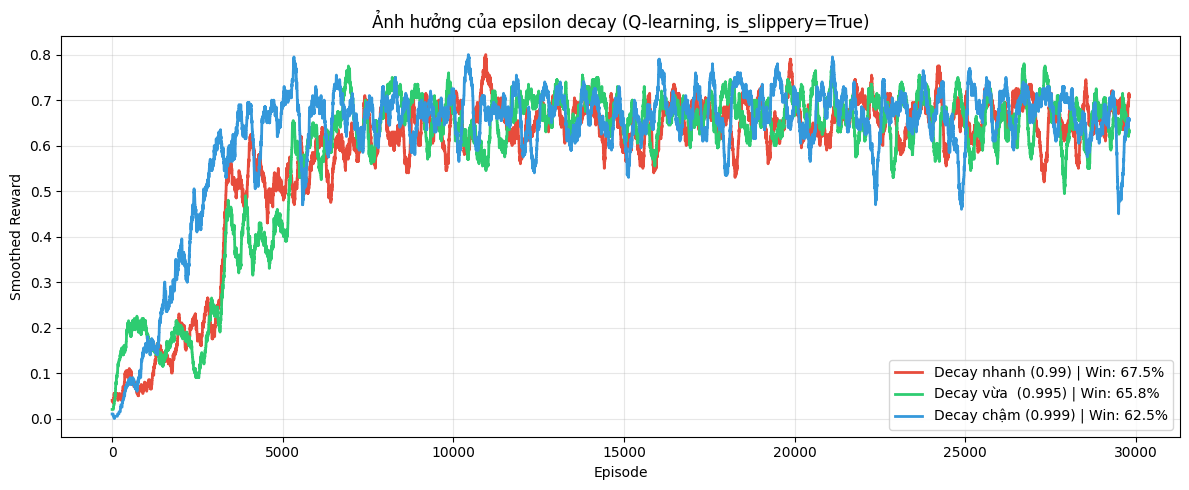

In [11]:
# Thử nghiệm 3 tốc độ decay epsilon khác nhau
decay_configs = {
    'Decay nhanh (0.99)':  0.990,
    'Decay vừa  (0.995)':  0.995,
    'Decay chậm (0.999)':  0.999,
}

colors = ['#e74c3c', '#2ecc71', '#3498db']
fig, ax = plt.subplots(figsize=(12, 5))

for (label, decay), color in zip(decay_configs.items(), colors):
    _, rewards = train_qlearning(env_slip, n_episodes, alpha, gamma, 1.0, 0.01, decay)
    sm = moving_average(rewards, 200)
    win = np.mean(rewards[-1000:]) * 100
    ax.plot(sm, color=color, lw=2, label=f'{label} | Win: {win:.1f}%')

ax.set_title('Ảnh hưởng của epsilon decay (Q-learning, is_slippery=True)', fontsize=12)
ax.set_xlabel('Episode')
ax.set_ylabel('Smoothed Reward')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét:

- Decay nhanh: agent dừng khám phá sớm → có thể bị kẹt ở policy chưa tối ưu  
- Decay chậm: khám phá lâu hơn → học kỹ hơn nhưng mất nhiều episode  
- Cần cân bằng giữa exploration (khám phá) và exploitation (khai thác)

## Phần 7: Đánh giá Agent

In [ ]:
def evaluate_agent(Q, env, n_eval=1000, render_one=True):
    """
    Đánh giá agent sau khi học: chạy greedy (không khám phá)
    và đếm bao nhiêu lần thắng.
    """
    wins = 0
    sample_path = []

    for ep in range(n_eval):
        state, _ = env.reset()
        done = False
        path = [state]

        while not done:
            action = np.argmax(Q[state])   # luôn chọn hành động tốt nhất
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            path.append(state)

        if reward == 1:
            wins += 1
            if render_one and len(sample_path) == 0:
                sample_path = path   # lưu một đường đi thắng để in

    win_rate = wins / n_eval * 100
    return win_rate, sample_path


# Đánh giá cả 2 thuật toán
wr_ql, path_ql = evaluate_agent(Q_qlearn, env_slip)
wr_sa, path_sa = evaluate_agent(Q_sarsa,  env_slip)

print(" KẾT QUẢ ĐÁNH GIÁ AGENT (1000 episodes, greedy policy)")
print(f"  Q-learning win rate : {wr_ql:.1f}%")
print(f"  SARSA      win rate : {wr_sa:.1f}%")

# In một đường đi mẫu
action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']
if path_ql:
    print(f"\n Một đường đi thắng của Q-learning (sample):")
    print("   Trạng thái:", ' → '.join(map(str, path_ql)))
    print(f"   Số bước: {len(path_ql)-1}")

 KẾT QUẢ ĐÁNH GIÁ AGENT (1000 episodes, greedy policy)
  Q-learning win rate : 75.1%
  SARSA      win rate : 74.6%

 Một đường đi thắng của Q-learning (sample):
   Trạng thái: 0 → 0 → 0 → 0 → 4 → 4 → 8 → 8 → 9 → 10 → 6 → 10 → 14 → 15
   Số bước: 13


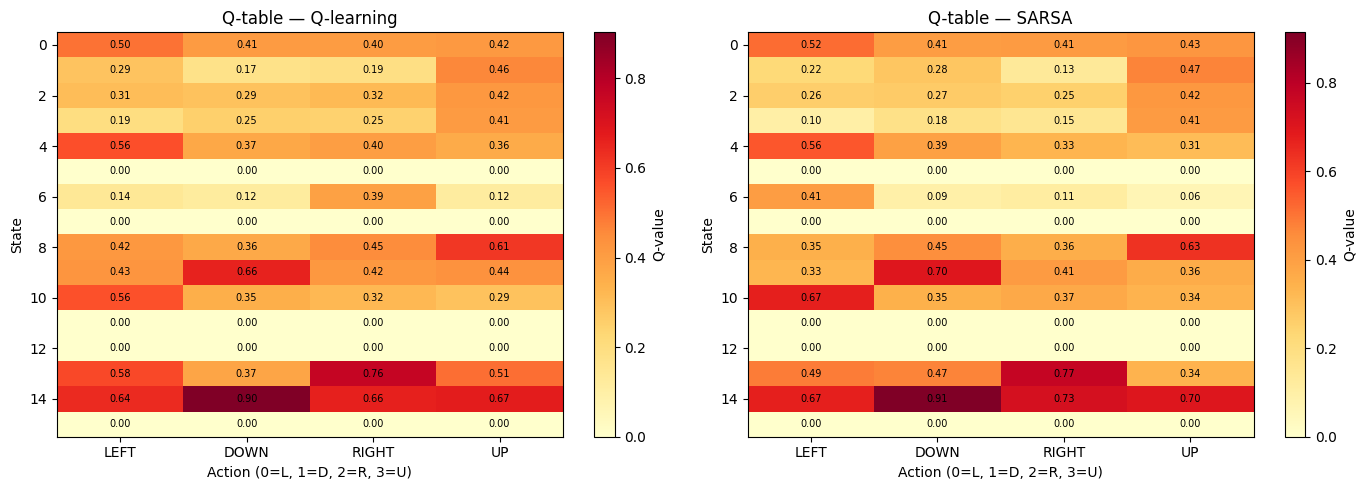

In [13]:
# Vẽ visualization Q-table dạng heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (Q, title) in zip(axes, [(Q_qlearn, 'Q-learning'), (Q_sarsa, 'SARSA')]):
    im = ax.imshow(Q, cmap='YlOrRd', aspect='auto')
    ax.set_title(f'Q-table — {title}', fontsize=12)
    ax.set_xlabel('Action (0=L, 1=D, 2=R, 3=U)')
    ax.set_ylabel('State')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['LEFT', 'DOWN', 'RIGHT', 'UP'])
    plt.colorbar(im, ax=ax, label='Q-value')

    # Thêm giá trị số vào từng ô
    for s in range(n_states):
        for a in range(n_actions):
            ax.text(a, s, f'{Q[s,a]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')

plt.tight_layout()
plt.savefig('qtable_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Phần 8

### Câu 1: Nguyên lý Q-learning và tại sao là off-policy?

**Q-learning** hoạt động bằng cách học một hàm giá trị $Q(s, a)$ — cho biết "nếu ta đang ở trạng thái $s$ và thực hiện hành động $a$, thì tổng phần thưởng kỳ vọng là bao nhiêu?". Agent sẽ dùng Q-table này để quyết định hành động tốt nhất ở mỗi bước.

Quá trình học diễn ra như sau:
1. Agent ở trạng thái $s$, chọn hành động $a$ theo ε-greedy
2. Nhận phần thưởng $r$ và chuyển sang trạng thái $s'$
3. Cập nhật Q-table:
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \right]$$

**Tại sao là off-policy?**  
Q-learning được gọi là off-policy vì khi cập nhật, nó **không quan tâm** agent sẽ thực sự làm gì tiếp theo. Nó dùng $\max_{a'} Q(s', a')$ — tức là giả định agent sẽ chọn hành động tốt nhất — dù thực tế agent có thể chọn ngẫu nhiên (do ε-greedy). Chính sách học (greedy) khác với chính sách hành động (ε-greedy) → **off-policy**.

---

### Câu 2: So sánh công thức Q-learning vs SARSA

| | **Q-learning** | **SARSA** |
|---|---|---|
| Công thức | $Q(s,a) \mathrel{+}= \alpha[r + \gamma \cdot \max Q(s',a') - Q(s,a)]$ | $Q(s,a) \mathrel{+}= \alpha[r + \gamma \cdot Q(s', a') - Q(s,a)]$ |
| Dùng gì để cập nhật | Giá trị Q của hành động **tốt nhất** ở $s'$ | Giá trị Q của hành động **thực tế** $a'$ tại $s'$ |
| Policy | Off-policy | On-policy |

**Ảnh hưởng đến chiến lược học:**  
- Q-learning học về policy **tối ưu lý thuyết** nên thường đạt Q-value cao hơn, nhưng khi môi trường có nhiều rủi ro, nó không tính đến hành vi thực tế (có thể ngẫu nhiên) → dễ đi qua vùng nguy hiểm hơn.  
- SARSA học về policy **agent thực sự đang dùng** (kể cả lúc khám phá ngẫu nhiên) → thận trọng hơn, tránh vùng nguy hiểm tốt hơn trong quá trình học.

---

### Câu 3: Vai trò của ε-greedy

ε-greedy giải quyết bài toán **exploration vs exploitation**:
- Với xác suất **ε**: chọn hành động **ngẫu nhiên** → *khám phá* trạng thái mới
- Với xác suất **1-ε**: chọn hành động **tốt nhất** theo Q-table → *khai thác* kiến thức đã học

**Nếu ε quá lớn (gần 1):**  
Agent hầu như luôn hành động ngẫu nhiên → không thể khai thác kiến thức đã học → tỉ lệ thắng thấp ngay cả sau nhiều episode.

**Nếu ε quá nhỏ (gần 0):**  
Agent hầu như luôn khai thác → ít khám phá → có thể bị mắc kẹt ở local optimum, không tìm được đường tốt hơn.

→ Giải pháp thường dùng: **epsilon decay** — bắt đầu ε cao (khám phá nhiều), giảm dần (khai thác nhiều hơn khi đã học đủ).

---

### Câu 4: Môi trường nguy hiểm → chọn thuật toán nào?

**SARSA an toàn hơn** trong môi trường nhiều rủi ro.

Lý do: SARSA là on-policy, cập nhật Q dựa trên hành động **thực sự sẽ làm** (có thể là hành động ngẫu nhiên do ε). Vì vậy, SARSA biết rằng "lúc huấn luyện, mình có thể đi ngẫu nhiên" → tránh những trạng thái gần lỗ/nguy hiểm ngay cả khi khám phá.  

Q-learning thì cập nhật dựa trên giả định "sẽ luôn chọn tốt nhất" → ước tính Q cao hơn thực tế ở vùng nguy hiểm → có xu hướng đi gần các trạng thái rủi ro hơn.  

Ví dụ trong FrozenLake: SARSA thường học cách đi vòng xa lỗ hơn, còn Q-learning đôi khi đi sát lỗ vì nó tin rằng "sẽ không rơi".

---

### Câu 5: Đồ thị reward dao động mạnh / không tăng — 3 nguyên nhân và cách khắc phục

**Nguyên nhân 1: Learning rate α quá lớn**  
Q-value cập nhật quá nhiều mỗi bước → không ổn định, liên tục dao động.  
✅ Khắc phục: Giảm α xuống (ví dụ từ 0.8 → 0.1), hoặc dùng decay cho α.

**Nguyên nhân 2: Epsilon không giảm (khám phá mãi)**  
Nếu ε luôn cao, agent không khai thác kiến thức đã học → reward vẫn ngẫu nhiên.  
✅ Khắc phục: Thêm epsilon decay đúng cách, đảm bảo ε giảm đủ nhanh sau vài nghìn episode.

**Nguyên nhân 3: Số episode quá ít hoặc môi trường quá khó**  
Agent chưa đủ thời gian khám phá hết không gian trạng thái → Q-table chưa hội tụ.  
✅ Khắc phục: Tăng số episode, hoặc thử khởi tạo Q-table với giá trị optimistic (ví dụ: đặt Q = 1 thay vì 0) để khuyến khích khám phá ban đầu.

KẾT QUẢ BENCHMARK (2000 lần chạy, greedy policy)
   Q-learning  : 73.4%  win rate
   SARSA       : 75.5%  win rate
Learning curve cuối cùng:


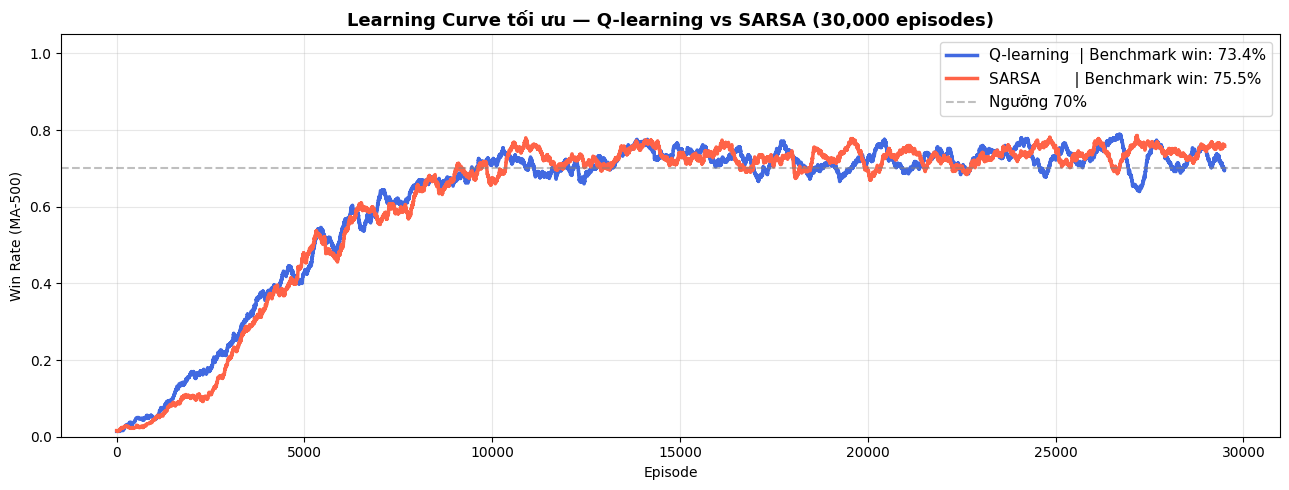

In [14]:
# So sánh tỉ lệ thắng trước và sau tối ưu Chạy nhiều lần để lấy trung bình (vì môi trường stochastic)

def benchmark(Q, env, n_runs=2000):
    """Chạy greedy policy n_runs lần, đếm tỉ lệ thắng."""
    wins = 0
    for _ in range(n_runs):
        state, _ = env.reset()
        done = False
        for _ in range(100):   # giới hạn bước, tránh vòng vô hạn
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                wins += reward
                break
    return wins / n_runs * 100

wr_ql_final = benchmark(Q_qlearn, env_slip)
wr_sa_final = benchmark(Q_sarsa,  env_slip)

print("KẾT QUẢ BENCHMARK (2000 lần chạy, greedy policy)")
print(f"   Q-learning  : {wr_ql_final:.1f}%  win rate")
print(f"   SARSA       : {wr_sa_final:.1f}%  win rate")
print("Learning curve cuối cùng:")

fig, ax = plt.subplots(figsize=(13, 5))
w = 500
sq = np.convolve(rewards_qlearn, np.ones(w)/w, mode='valid')
ss = np.convolve(rewards_sarsa,  np.ones(w)/w, mode='valid')

ax.plot(sq, color='royalblue', lw=2.5,
        label=f'Q-learning  | Benchmark win: {wr_ql_final:.1f}%')
ax.plot(ss, color='tomato',    lw=2.5,
        label=f'SARSA       | Benchmark win: {wr_sa_final:.1f}%')

ax.axhline(y=0.7, color='gray', ls='--', alpha=0.5, label='Ngưỡng 70%')
ax.set_title('Learning Curve tối ưu — Q-learning vs SARSA (30,000 episodes)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Win Rate (MA-500)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('final_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Tổng kết

Qua bài lab này, em đã:

| Nội dung | Hoàn thành |
|---|---|
| Hiểu và cài đặt Q-learning | ✅ |
| Hiểu và cài đặt SARSA | ✅ |
| So sánh 2 thuật toán trực quan | ✅ |
| Thử nghiệm slippery / epsilon decay | ✅ |
| Đánh giá agent sau huấn luyện | ✅ |
| Trả lời 5 câu hỏi lý thuyết | ✅ |

**Điểm mấu chốt cần nhớ:** Q-learning (off-policy) học nhanh hơn trong môi trường xác định, còn SARSA (on-policy) an toàn hơn trong môi trường có nhiều rủi ro. Epsilon-greedy là "trái tim" của cả hai thuật toán — cân bằng giữa khám phá và khai thác.